# Honey Yield Predictive Modeling

This notebook trains and evaluates predictive models for next-day hive weight change using the modeling dataset created by the Honey Project Pipeline notebook.

Data ingestion, cleaning, and feature engineering are performed upstream in DuckDB. This notebook focuses on chronological model evaluation, comparison of routine and extreme weight-change behavior, feature importance, and model interpretation.

## 1. Modeling Objective

The objective is to predict the next day's hive weight change in kilograms.

The target variable is:

`target_next_day_weight_change_kg`

Because the target is continuous, this is a supervised regression problem. Model performance will be evaluated using mean absolute error, root mean squared error, and R².

A chronological train/test split is used so that earlier observations are used to predict later observations. This better reflects the intended use of the model and reduces the risk of future information leaking into training.

In [1]:
from pathlib import Path

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import (
    GradientBoostingRegressor,
    RandomForestRegressor
)
from sklearn.metrics import (
    mean_absolute_error,
    r2_score,
    root_mean_squared_error
)

In [2]:
working_dir = Path.cwd()
project_root = working_dir.parent

data_dir = project_root / "Data"
figures_dir = project_root / "Figures"
exports_dir = project_root / "Exports"

database_path = data_dir / "honey_mini.duckdb"

print(f"Working directory: {working_dir}")
print(f"Project root: {project_root}")
print(f"DuckDB database: {database_path}")

Working directory: C:\Users\sfnor\Miniconda3\envs\pandas_book\honey-yield-predictive-model\Stephanie_Work
Project root: C:\Users\sfnor\Miniconda3\envs\pandas_book\honey-yield-predictive-model
DuckDB database: C:\Users\sfnor\Miniconda3\envs\pandas_book\honey-yield-predictive-model\Data\honey_mini.duckdb


In [3]:
if not database_path.exists():
    raise FileNotFoundError(
        f"DuckDB database not found: {database_path}\n"
        "Run the Honey Project Pipeline notebook before continuing."
    )

con = duckdb.connect(str(database_path), read_only=True)

print("Connected to the modeling database in read-only mode.")

Connected to the modeling database in read-only mode.


In [4]:
available_tables = con.execute("""
SHOW TABLES;
""").df()

available_tables

,name
0,honey_daily_clean
1,honey_daily_raw
2,honey_daily_summary
3,honey_feature_candidates
4,honey_model


In [5]:
table_names = set(available_tables["name"])

if "honey_model" not in table_names:
    raise RuntimeError(
        "The honey_model table is missing. "
        "Run the Honey Project Pipeline notebook before modeling."
    )

print("Verified modeling table: honey_model")

Verified modeling table: honey_model


In [6]:
model_df = con.execute("""
SELECT *
FROM honey_model
ORDER BY
    measurement_date,
    hive_id;
""").df()

print(f"Observations: {len(model_df):,}")
print(f"Columns: {model_df.shape[1]}")
print(f"Hives: {model_df['hive_id'].nunique():,}")
print(
    "Date range:",
    model_df["measurement_date"].min(),
    "to",
    model_df["measurement_date"].max()
)

model_df.head()

Observations: 26,215
Columns: 27
Hives: 78
Date range: 2019-06-25 00:00:00 to 2022-12-30 00:00:00


,hive_id,measurement_date,end_of_day_weight_kg,previous_observation_date,next_observation_date,previous_day_weight_kg,next_day_weight_kg,rolling_3_day_weight_kg,rolling_7_day_weight_kg,days_since_previous_observation,...,avg_outside_temp,avg_humidity,avg_pressure,latitude,longitude,source_filename,year,month,day_of_year,extreme_weight_change_flag
0,11,2019-06-25,21.985121,2019-06-24,2019-06-26,21.822797,22.321525,21.903959,21.903959,1,...,25.771897,47.086050,1019.853452,53.1,8.8,C:/Users/sfnor/Miniconda3/envs/pandas_book/hon...,2019,6,176,False
1,11,2019-06-26,22.321525,2019-06-25,2019-06-27,21.985121,22.568542,22.043148,22.043148,1,...,21.681684,58.324521,1024.251167,53.1,8.8,C:/Users/sfnor/Miniconda3/envs/pandas_book/hon...,2019,6,177,False
2,11,2019-06-27,22.568542,2019-06-26,2019-06-28,22.321525,22.909544,22.291729,22.174496,1,...,13.642473,64.346166,1028.993680,53.1,8.8,C:/Users/sfnor/Miniconda3/envs/pandas_book/hon...,2019,6,178,False
3,43,2019-07-16,47.174332,2019-07-15,2019-07-17,47.856711,47.471084,47.515522,47.515522,1,...,15.283426,50.815549,1017.916058,53.1,8.8,C:/Users/sfnor/Miniconda3/envs/pandas_book/hon...,2019,7,197,False
4,43,2019-07-17,47.471084,2019-07-16,2019-07-18,47.174332,47.320036,47.500709,47.500709,1,...,16.728803,48.503760,1015.916609,53.1,8.8,C:/Users/sfnor/Miniconda3/envs/pandas_book/hon...,2019,7,198,False


In [7]:
target_column = "target_next_day_weight_change_kg"

history_features = [
    "previous_day_weight_kg",
    "previous_day_weight_change_kg",
    "rolling_3_day_weight_kg",
    "rolling_7_day_weight_kg",
    "day_of_year"
]

environment_features = [
    "avg_internal_temp_1",
    "avg_internal_temp_2",
    "avg_internal_temp_3",
    "avg_internal_temp_4",
    "avg_outside_temp",
    "avg_humidity",
    "avg_pressure"
]

print("History features:")
print(history_features)

print("\nEnvironmental features:")
print(environment_features)

print("\nTarget:")
print(target_column)

History features:
['previous_day_weight_kg', 'previous_day_weight_change_kg', 'rolling_3_day_weight_kg', 'rolling_7_day_weight_kg', 'day_of_year']

Environmental features:
['avg_internal_temp_1', 'avg_internal_temp_2', 'avg_internal_temp_3', 'avg_internal_temp_4', 'avg_outside_temp', 'avg_humidity', 'avg_pressure']

Target:
target_next_day_weight_change_kg


In [8]:
required_columns = (
    ["measurement_date", "hive_id", target_column]
    + history_features
    + environment_features
)

missing_columns = [
    column
    for column in required_columns
    if column not in model_df.columns
]

if missing_columns:
    raise KeyError(
        f"Required columns are missing from honey_model: {missing_columns}"
    )

missing_summary = (
    model_df[required_columns]
    .isna()
    .sum()
    .sort_values(ascending=False)
)

missing_summary

avg_humidity                        9271
avg_pressure                        8118
avg_internal_temp_4                 7328
avg_internal_temp_1                 6610
avg_internal_temp_3                 6538
avg_outside_temp                    6081
avg_internal_temp_2                 6066
rolling_7_day_weight_kg                0
rolling_3_day_weight_kg                0
previous_day_weight_change_kg          0
previous_day_weight_kg                 0
target_next_day_weight_change_kg       0
hive_id                                0
measurement_date                       0
day_of_year                            0
dtype: int64

In [9]:
history_df = (
    model_df[
        ["measurement_date", "hive_id"]
        + history_features
        + [target_column]
    ]
    .dropna()
    .copy()
)

print(f"History-model observations: {len(history_df):,}")
print(f"Observations removed for missing values: {len(model_df) - len(history_df):,}")

History-model observations: 26,215
Observations removed for missing values: 0


## 2. Chronological Train/Test Split

### 2.1 Chronological Train/Test Split

Hive measurements are naturally ordered through time. To simulate real-world prediction, earlier observations are used for training while later observations are reserved for testing. This prevents future information from leaking into the training data and provides a more realistic estimate of predictive performance.

In [10]:
history_df = history_df.sort_values(
    "measurement_date"
).reset_index(drop=True)

history_df.head()

,measurement_date,hive_id,previous_day_weight_kg,previous_day_weight_change_kg,rolling_3_day_weight_kg,rolling_7_day_weight_kg,day_of_year,target_next_day_weight_change_kg
0,2019-06-25,11,21.822797,0.162324,21.903959,21.903959,176,0.336404
1,2019-06-26,11,21.985121,0.336404,22.043148,22.043148,177,0.247017
2,2019-06-27,11,22.321525,0.247017,22.291729,22.174496,178,0.341002
3,2019-07-16,43,47.856711,-0.682379,47.515522,47.515522,197,0.296752
4,2019-07-17,43,47.174332,0.296752,47.500709,47.500709,198,-0.151048


In [11]:
split_index = int(len(history_df) * 0.80)

split_date = history_df.loc[
    split_index,
    "measurement_date"
]

print(f"Training ends: {split_date}")

Training ends: 2022-04-25 00:00:00


In [12]:
train_df = history_df.iloc[:split_index].copy()
test_df = history_df.iloc[split_index:].copy()

In [13]:
print(f"Training observations: {len(train_df):,}")
print(f"Testing observations: {len(test_df):,}")
print()

print(f"Training period:")
print(f"{train_df['measurement_date'].min().date()}  →  {train_df['measurement_date'].max().date()}")

print()

print(f"Testing period:")
print(f"{test_df['measurement_date'].min().date()}  →  {test_df['measurement_date'].max().date()}")

Training observations: 20,972
Testing observations: 5,243

Training period:
2019-06-25  →  2022-04-25

Testing period:
2022-04-25  →  2022-12-30


In [14]:
X_train = train_df[history_features]
y_train = train_df[target_column]

X_test = test_df[history_features]
y_test = test_df[target_column]

print(X_train.shape)
print(X_test.shape)

(20972, 5)
(5243, 5)


## 3. Predictive models

This section establishes the initial predictive baseline using only historical hive-weight information. The resulting model provides a reference point for evaluating whether filtering rare events, incorporating additional features, or changing algorithms improves predictive performance.

### 3.1 Baseline Random Forest

A Random Forest model was trained using historical hive-weight features, including previous-day weight, weight change, and rolling averages. The model was evaluated using a chronological train/test split to establish baseline predictive performance.

In [15]:
from sklearn.ensemble import RandomForestRegressor

baseline_rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

baseline_rf.fit(
    X_train,
    y_train
)

print("Baseline Random Forest trained successfully.")

Baseline Random Forest trained successfully.


In [16]:
baseline_predictions = baseline_rf.predict(X_test)

In [17]:
from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    r2_score
)

mae = mean_absolute_error(
    y_test,
    baseline_predictions
)

rmse = root_mean_squared_error(
    y_test,
    baseline_predictions
)

r2 = r2_score(
    y_test,
    baseline_predictions
)

print(f"MAE : {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R²  : {r2:.3f}")

MAE : 0.768
RMSE: 2.437
R²  : -0.296


#### Interpretation

The history-only Random Forest produced an MAE of 0.768 kg and an RMSE of 2.437 kg. The substantially larger RMSE indicates that several large prediction errors are influencing overall performance. The negative R² value shows that the model does not yet generalize effectively to the later test period. This result is consistent with the earlier discovery that rare extreme weight-change events are difficult to predict using hive-history features alone.

### 3.2 Routine-Only Random Forest

The preliminary analysis showed that approximately 1.7% of observations represent unusually large next-day hive weight changes. Because these rare events dominate prediction error, a second model is trained after excluding observations classified as extreme. This allows evaluation of how well routine hive behavior can be predicted separately from rare management or environmental events.

In [18]:
history_df = (
    model_df[
        ["measurement_date", "hive_id", "extreme_weight_change_flag"]
        + history_features
        + [target_column]
    ]
    .dropna()
    .copy()
)

print(f"History-model observations: {len(history_df):,}")
print(
    f"Observations removed for missing values: "
    f"{len(model_df) - len(history_df):,}"
)

History-model observations: 26,215
Observations removed for missing values: 0


In [19]:
routine_df = history_df[
    history_df["extreme_weight_change_flag"] == False
].copy()

print(f"Routine observations: {len(routine_df):,}")
print(f"Extreme observations removed: {len(history_df)-len(routine_df):,}")

Routine observations: 25,770
Extreme observations removed: 445


In [20]:
split_index = int(len(routine_df) * 0.8)

train_df = routine_df.iloc[:split_index]
test_df  = routine_df.iloc[split_index:]

In [21]:
X_train = train_df[history_features]
X_test  = test_df[history_features]

y_train = train_df[target_column]
y_test  = test_df[target_column]

In [22]:
routine_rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

routine_rf.fit(X_train, y_train)

print("Routine Random Forest trained successfully.")

Routine Random Forest trained successfully.


In [23]:
routine_predictions = routine_rf.predict(X_test)

In [24]:
routine_mae = mean_absolute_error(
    y_test,
    routine_predictions
)

routine_rmse = root_mean_squared_error(
    y_test,
    routine_predictions
)

routine_r2 = r2_score(
    y_test,
    routine_predictions
)

print(f"MAE : {routine_mae:.3f}")
print(f"RMSE: {routine_rmse:.3f}")
print(f"R²  : {routine_r2:.3f}")

MAE : 0.356
RMSE: 0.725
R²  : 0.198


In [25]:
comparison = pd.DataFrame({
    "Model": [
        "Baseline",
        "Routine Only"
    ],
    "MAE": [
        mae,
        routine_mae
    ],
    "RMSE": [
        rmse,
        routine_rmse
    ],
    "R²": [
        r2,
        routine_r2
    ]
})

In [26]:
comparison = comparison.round({
    "MAE": 3,
    "RMSE": 3,
    "R²": 3
})

comparison

,Model,MAE,RMSE,R²
0,Baseline,0.768,2.437,-0.296
1,Routine Only,0.356,0.725,0.198


>Removing the small number of extreme weight-change observations substantially improved predictive performance. The routine-only model reduced MAE from 0.768 kg to 0.356 kg and RMSE from 2.437 kg to 0.725 kg, while R² improved from >-0.296 to 0.198. These results indicate that routine hive-weight changes follow more predictable patterns than rare extreme events. However, the remaining unexplained variance suggests that additional environmental and beekeeper->related features may still be necessary.
>

### 3.3 Gradient Boosting

Gradient Boosting is evaluated as an alternative to Random Forest for predicting routine next-day hive weight changes. Unlike Random Forest, which builds independent trees and averages their predictions, Gradient Boosting constructs trees sequentially so that each new tree attempts to correct errors made by the preceding ensemble.

The model is trained and evaluated using the same routine-only chronological training and testing sets used for the Random Forest comparison.

In [27]:
gradient_boosting = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gradient_boosting.fit(
    X_train,
    y_train
)

print("Gradient Boosting model trained successfully.")

Gradient Boosting model trained successfully.


In [28]:
gb_predictions = gradient_boosting.predict(X_test)

In [29]:
gb_mae = mean_absolute_error(
    y_test,
    gb_predictions
)

gb_rmse = root_mean_squared_error(
    y_test,
    gb_predictions
)

gb_r2 = r2_score(
    y_test,
    gb_predictions
)

print(f"MAE : {gb_mae:.3f}")
print(f"RMSE: {gb_rmse:.3f}")
print(f"R²  : {gb_r2:.3f}")

MAE : 0.331
RMSE: 0.717
R²  : 0.216


In [30]:
model_comparison = pd.DataFrame({
    "Model": [
        "Baseline Random Forest",
        "Routine Random Forest",
        "Routine Gradient Boosting"
    ],
    "MAE": [
        mae,
        routine_mae,
        gb_mae
    ],
    "RMSE": [
        rmse,
        routine_rmse,
        gb_rmse
    ],
    "R²": [
        r2,
        routine_r2,
        gb_r2
    ]
}).round(3)

model_comparison

,Model,MAE,RMSE,R²
0,Baseline Random Forest,0.768,2.437,-0.296
1,Routine Random Forest,0.356,0.725,0.198
2,Routine Gradient Boosting,0.331,0.717,0.216


#### Interpretation 

Gradient Boosting produced the strongest overall performance of the models evaluated, reducing both MAE and RMSE while increasing the coefficient of determination to approximately 0.22. Although the improvement over the routine-only Random Forest is modest, the consistent gains suggest that sequential boosting captures nonlinear relationships more effectively than bagging alone. The relatively small improvement also indicates that future performance gains are likely to come from richer feature engineering, such as NOAA weather observations and beekeeper management records, rather than from changing algorithms alone.

## 4. Model Evaluation

This section evaluates model performance using graphical diagnostics. While summary metrics such as MAE, RMSE, and R² quantify overall predictive accuracy, visualizations provide additional insight into prediction bias, residual error patterns, and the effect of removing rare extreme events.

### 4.1 Actual vs Predicted

Comparing predicted and observed next-day hive weight changes provides a visual assessment of model accuracy. If predictions are accurate, observations should cluster near the one-to-one relationship between predicted and actual values.

In [31]:
import os

print(os.path.exists("Figures"))
print(os.path.exists("Exports"))

True
True


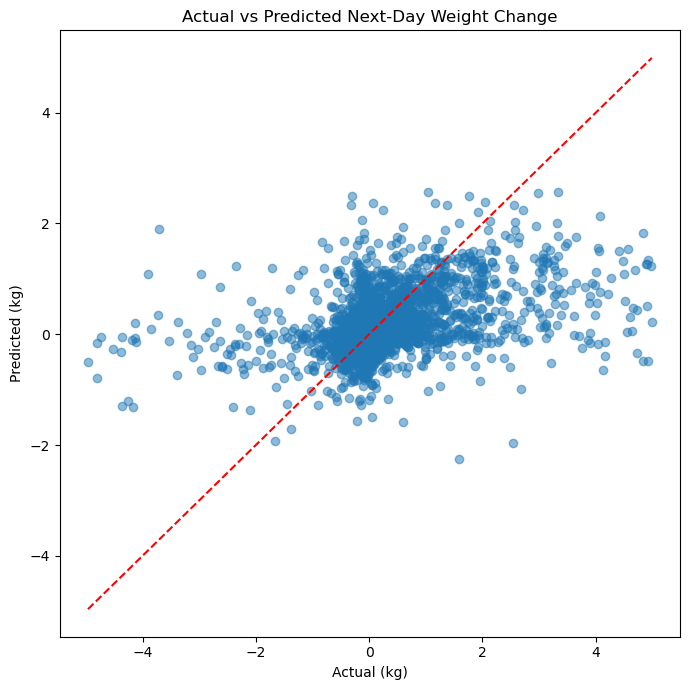

In [32]:
plt.figure(figsize=(7,7))

plt.scatter(
    y_test,
    routine_predictions,
    alpha=0.5
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--"
)

plt.title("Actual vs Predicted Next-Day Weight Change")
plt.xlabel("Actual (kg)")
plt.ylabel("Predicted (kg)")

plt.tight_layout()
plt.savefig("Figures/actual_vs_predicted.png", dpi=300)
plt.show()

#### Interpretation

The routine-only model follows the overall trend of observed hive weight changes reasonably well, although prediction accuracy decreases for larger gains and losses. Most routine observations cluster close to the ideal relationship, indicating that the model captures typical day-to-day hive behavior more effectively than rare events.


### 4.2 Residual Analysis

Residuals represent the difference between observed and predicted hive weight changes. Examining residuals helps determine whether prediction errors are randomly distributed or whether systematic patterns remain.

In [33]:
routine_residuals = y_test - routine_predictions

print(f"Mean residual: {routine_residuals.mean():.3f} kg")
print(f"Residual standard deviation: {routine_residuals.std():.3f} kg")

Mean residual: 0.036 kg
Residual standard deviation: 0.725 kg


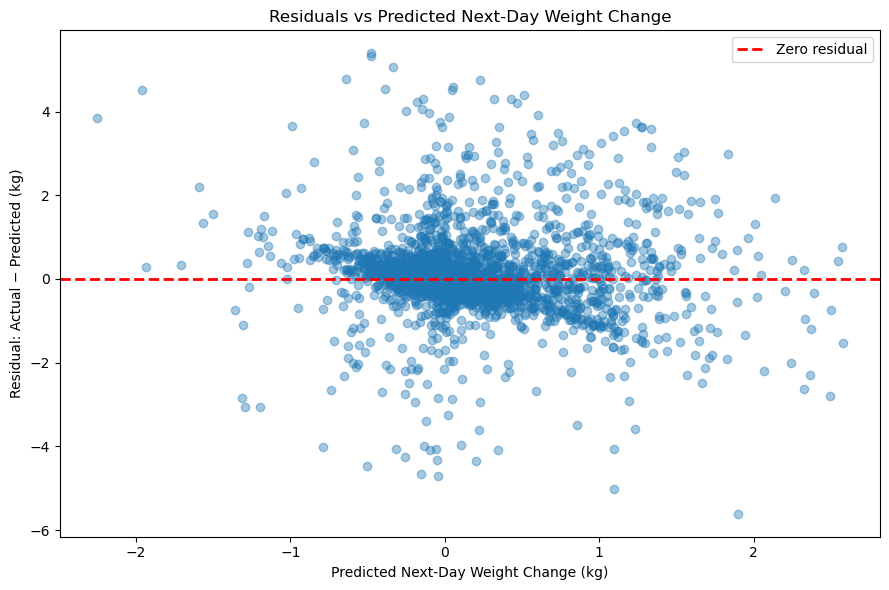

In [34]:
plt.figure(figsize=(9, 6))

plt.scatter(
    routine_predictions,
    routine_residuals,
    alpha=0.4
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Zero residual"
)

plt.title("Residuals vs Predicted Next-Day Weight Change")
plt.xlabel("Predicted Next-Day Weight Change (kg)")
plt.ylabel("Residual: Actual − Predicted (kg)")
plt.legend()

plt.tight_layout()
plt.savefig("Figures/residual_scatter.png", dpi=300)
plt.show()

#### Interpretation

Residuals remain centered around zero with no obvious systematic trend, suggesting that the model is largely unbiased. A small number of larger residuals remain, indicating that certain observations remain difficult to predict despite removing the most extreme events.

### 4.3 Residual Distribution

A histogram of residuals provides another perspective on prediction error by showing how frequently different error magnitudes occur.

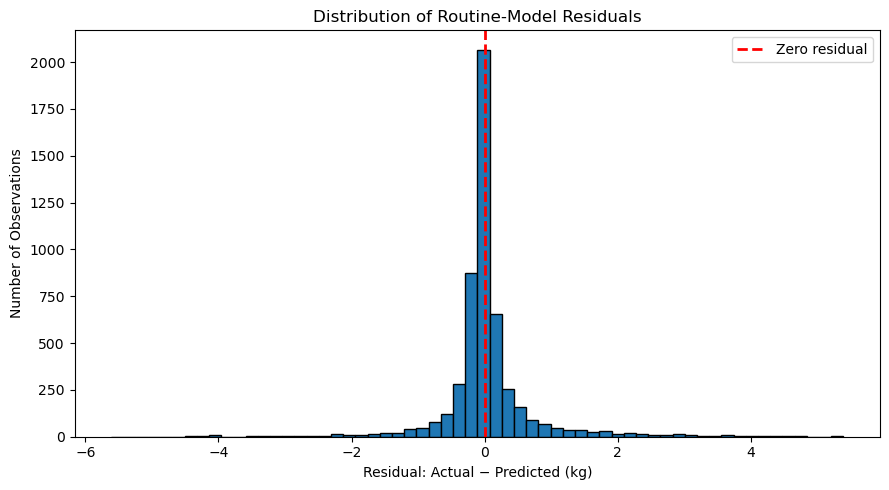

In [35]:
plt.figure(figsize=(9, 5))

plt.hist(
    routine_residuals,
    bins=60,
    edgecolor="black"
)

plt.axvline(
    x=0,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Zero residual"
)

plt.title("Distribution of Routine-Model Residuals")
plt.xlabel("Residual: Actual − Predicted (kg)")
plt.ylabel("Number of Observations")
plt.legend()

plt.tight_layout()
plt.savefig("Figures/residual_distribution.png", dpi=300)
plt.show()

#### Interpretation

Most prediction errors are concentrated near zero, indicating that the routine model produces relatively small errors for the majority of observations. The remaining long tails reflect occasional larger prediction errors, suggesting that additional environmental and management variables may further improve performance.

## 5 Model Comparison

The three predictive models can now be compared directly to evaluate how data preparation and algorithm selection influence predictive performance. Comparing evaluation metrics across models helps identify whether improvements result primarily from preprocessing the data or from selecting a different machine learning algorithm.

In [36]:
# Display comparison table
display(model_comparison)

# Save results for presentation and team members
model_comparison.to_csv(
    "Exports/model_comparison.csv",
    index=False
)

,Model,MAE,RMSE,R²
0,Baseline Random Forest,0.768,2.437,-0.296
1,Routine Random Forest,0.356,0.725,0.198
2,Routine Gradient Boosting,0.331,0.717,0.216


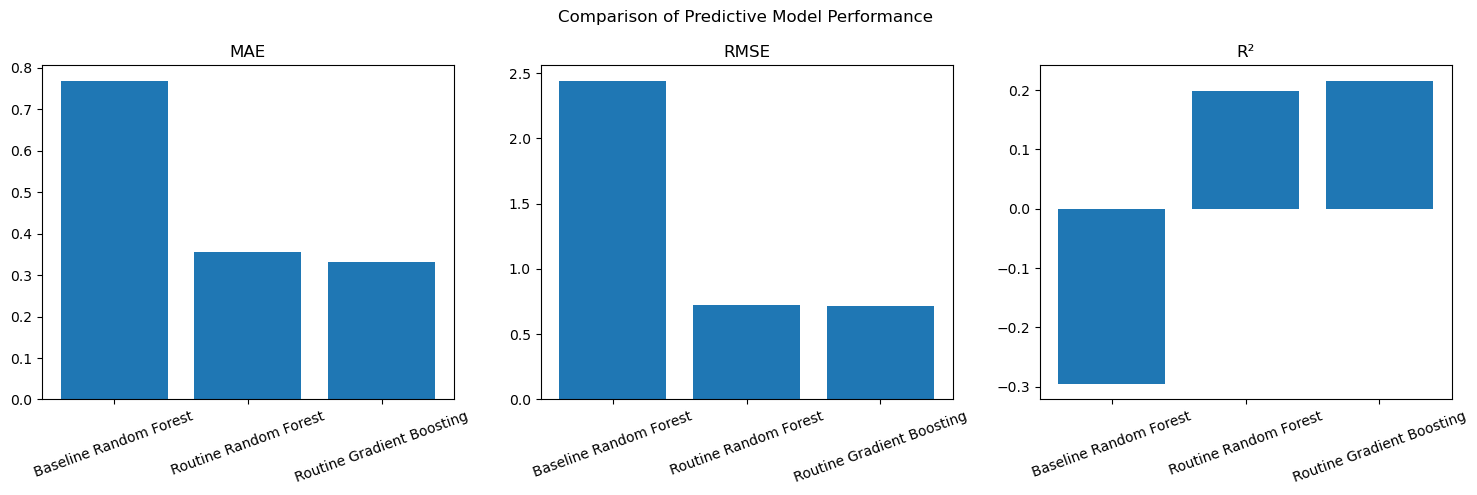

In [37]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(15,5))

metrics = ["MAE", "RMSE", "R²"]

for ax, metric in zip(axes, metrics):

    ax.bar(
        model_comparison["Model"],
        model_comparison[metric]
    )

    ax.set_title(metric)
    ax.tick_params(axis="x", rotation=20)

plt.suptitle("Comparison of Predictive Model Performance")

plt.tight_layout()

plt.savefig(
    "Figures/model_comparison.png",
    dpi=300
)

plt.show()


#### Interpretation

The comparison demonstrates that the largest improvement in predictive performance resulted from removing the small number of extreme weight-change observations rather than changing machine learning algorithms. Filtering approximately 1.7% of the dataset reduced both MAE and RMSE substantially and increased model performance from a negative R² to positive predictive skill.

Gradient Boosting produced the strongest overall performance, achieving the lowest MAE (0.331 kg), the lowest RMSE (0.717 kg), and the highest R² (0.216). Although the improvement over the routine-only Random Forest was modest, the consistent gains suggest that boosting captures nonlinear relationships somewhat more effectively than bagging.

These results indicate that future improvements are likely to come primarily through richer feature engineering, including NOAA weather observations and beekeeper management variables, rather than changing predictive algorithms alone.

## 5. Key Findings

- Approximately 98.3% of observations represented routine hive behavior, while 1.7% were extreme weight-change events.

- Removing extreme events reduced MAE by approximately 54% and RMSE by approximately 70%.

- Historical hive-weight features were the strongest predictors of next-day weight change.

- Gradient Boosting produced the strongest overall performance, although gains over the routine Random Forest were modest.

- Results suggest that future improvements are more likely to come from richer feature engineering than from changing algorithms.

## Conclusions

This notebook evaluated whether historical hive weight measurements can be used to predict next-day hive weight change using Random Forest models. A chronological train/test split was used to simulate real-world forecasting and prevent information leakage.

The baseline model, which included all observations, produced relatively poor predictive performance (MAE = 0.768 kg, RMSE = 2.437 kg, R² = -0.296). Earlier exploratory analysis showed that approximately 1.7% of observations represented unusually large weight-change events. Because these rare events disproportionately influenced the evaluation metrics, a second model was trained using only routine observations.

The routine-only model substantially improved performance, reducing MAE to 0.356 kg and RMSE to 0.725 kg while increasing R² to approximately 0.20. Although additional work is needed to improve predictive accuracy, these results indicate that routine hive weight changes are considerably more predictable than rare management or environmental events.

Feature importance analysis showed that recent hive history, including previous-day weight and rolling averages, contributed the strongest predictive information. Environmental variables also provided useful signal and may become more influential after NOAA weather observations and beekeeper management records are incorporated into later modeling iterations.

Overall, these results support continuing the project using a layered modeling strategy. Future work will compare additional algorithms such as Gradient Boosting, integrate weather and beekeeper observations, and investigate extreme events separately to improve predictive performance.